<a href="https://colab.research.google.com/github/AfzalNavas/northstar-analytics/blob/main/notebooks/PYTHON_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
app_events = pd.read_csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/Cleaned%20CSV/clean_app_events.csv")

print("Basic details for the Data:")
print(app_events.describe())

Basic details for the Data:
       api_latency_ms  success_flag
count      640.000000    640.000000
mean       465.667188      0.940625
std        271.634155      0.236510
min         60.000000      0.000000
25%        278.750000      1.000000
50%        432.500000      1.000000
75%        609.000000      1.000000
max       1701.000000      1.000000


In [ ]:
total_no_events = app_events['event_id'].count()
no_linked_events = app_events['order_id'].count()
no_orphaned_events = total_no_events - no_linked_events

print("The total number of events in the app are:", total_no_events)
print("the number of events with linked orders are:", no_linked_events)
print("the number of Orphaned Events (the ones with no order ID) are:", no_orphaned_events)

The total number of events in the app are: 640
the number of events with linked orders are: 496
the number of Orphaned Events (the ones with no order ID) are: 144


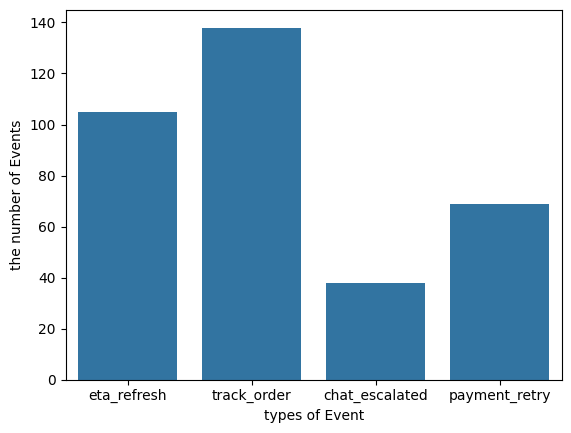

In [ ]:
eta_track = app_events[app_events['event_type'] == 'eta_refresh']['event_id'].count()
track_track  = app_events[app_events['event_type'] == 'track_order']['event_id'].count()
chat_track  = app_events[app_events['event_type'] == 'chat_escalated']['event_id'].count()
pay_track  = app_events[app_events['event_type'] == 'payment_retry']['event_id'].count()

event_names =['eta_refresh', 'track_order', 'chat_escalated', 'payment_retry']
event_track = [eta_track, track_track , chat_track, pay_track]

sns.barplot(x=event_names, y=event_track)
plt.xlabel("types of Event")
plt.ylabel("the number of Events")
plt.show()


 the total platform failure rate is: 0.059375


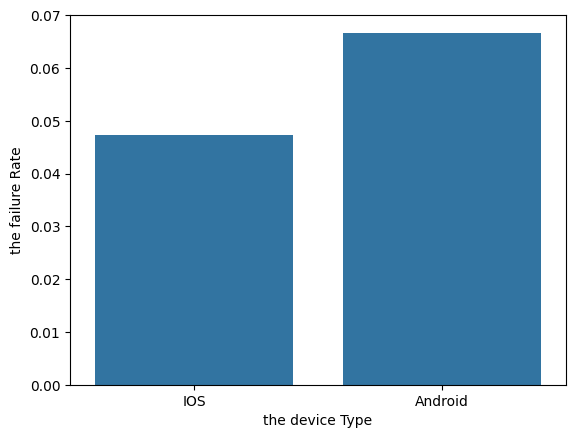

In [ ]:
total_success = app_events['success_flag'].sum()
total_failure_rate = (total_no_events - total_success) / total_no_events
print("\n the total platform failure rate is:", total_failure_rate)

total_ios_count = app_events[app_events['device_type'] == 'iOS']['event_id'].count()
ios_success_rate = app_events[app_events['device_type'] == 'iOS']['success_flag'].sum()
ios_failure_rate = (total_ios_count - ios_success_rate) / total_ios_count

total_android_count = app_events[app_events['device_type'] == 'Android']['event_id'].count()
android_success_rate = app_events[app_events['device_type'] == 'Android']['success_flag'].sum()
android_failure_rate = (total_android_count - android_success_rate) / total_android_count

devices =['IOS', 'Android']
total_fail_rates = [ios_failure_rate, android_failure_rate]

sns.barplot(x=devices, y=total_fail_rates)
plt.xlabel("the device Type")
plt.ylabel("the failure Rate")
plt.show()

the average Latency is: 465.6671875
the Max Latency is: 1701
the deviation is: 271.421858319001


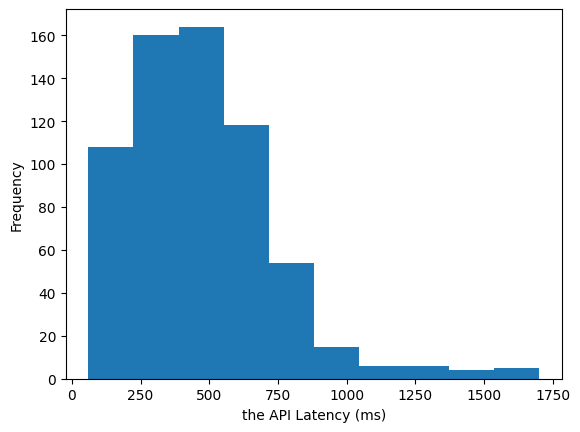

In [ ]:
latency_info = app_events['api_latency_ms'].values

print("the average Latency is:", np.mean(latency_info))
print("the Max Latency is:", np.max(latency_info))
print("the deviation is:", np.std(latency_info))

plt.hist(app_events['api_latency_ms'])
plt.xlabel("the API Latency (ms)")
plt.ylabel("Frequency")
plt.show()

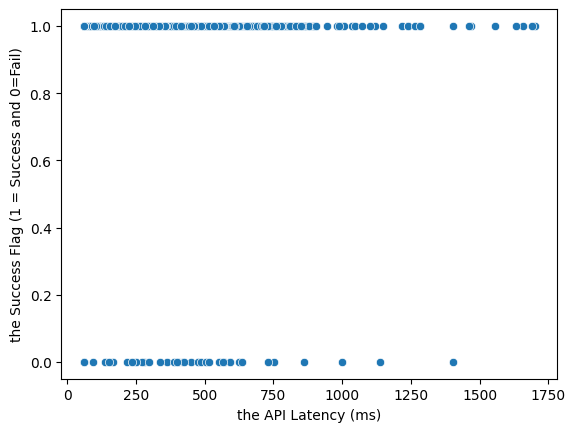

In [ ]:
sns.scatterplot(x=app_events['api_latency_ms'], y=app_events['success_flag'])
plt.xlabel("the API Latency (ms)")
plt.ylabel("the Success Flag (1 = Success and 0=Fail)")
plt.show()